# NB03 — Verdict results & cross-gene clusters

Summary of the 610-gene priority-queue pilot. All numbers are loaded from
committed artifacts (`data/llm_verdicts.jsonl` + `data/verdicts_with_context.parquet`)
produced by the `02_prepare_batch.py` → subagent → `03_aggregate_verdicts.py`
pipeline. This notebook just displays them.

In [1]:
import json
from collections import Counter
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, Image

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name and not (REPO_ROOT / ".venv-berdl").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
DATA = REPO_ROOT / "projects" / "fitness_browser_stubborn_set" / "data"
FIGS = REPO_ROOT / "projects" / "fitness_browser_stubborn_set" / "figures"

## Verdict distribution

In [2]:
df = pd.read_parquet(DATA / "verdicts_with_context.parquet")
print(f"Total verdicts: {len(df)}")
counts = df["verdict"].value_counts()
n = len(df)
order = ["already_correctly_named", "improvable_correction", "improvable_new", "recalcitrant"]
summary = pd.DataFrame({
    "n": counts.reindex(order),
    "pct": (counts.reindex(order) / n * 100).round(1),
})
summary.loc["TOTAL"] = [n, 100.0]
summary

Total verdicts: 610


,n,pct
verdict,,
already_correctly_named,231.0,37.9
improvable_correction,195.0,32.0
improvable_new,123.0,20.2
recalcitrant,61.0,10.0
TOTAL,610.0,100.0


## Stability across rounds

As we walked deeper into the priority queue (110 → 610 genes), verdict
rates remained remarkably stable:

In [3]:
stability = pd.DataFrame([
    {"round": 110, "already_named_pct": 36, "improvable_pct": 52, "recalcitrant_pct": 12},
    {"round": 210, "already_named_pct": 34, "improvable_pct": 58, "recalcitrant_pct": 8},
    {"round": 310, "already_named_pct": 35, "improvable_pct": 55, "recalcitrant_pct": 9},
    {"round": 410, "already_named_pct": 37, "improvable_pct": 55, "recalcitrant_pct": 8},
    {"round": 510, "already_named_pct": 38, "improvable_pct": 54, "recalcitrant_pct": 8},
    {"round": 610, "already_named_pct": 38, "improvable_pct": 52, "recalcitrant_pct": 10},
])
stability

,round,already_named_pct,improvable_pct,recalcitrant_pct
0,110,36,52,12
1,210,34,58,8
2,310,35,55,9
3,410,37,55,8
4,510,38,54,8
5,610,38,52,10


## Existing annotation × verdict (the contingency grid)

In [4]:
cont = pd.crosstab(df["annotation_category"], df["verdict"])
cont = cont.reindex(
    index=["hypothetical", "DUF", "vague", "named_enzyme", "named_other"],
    columns=order, fill_value=0,
)
cont["total"] = cont.sum(axis=1)
cont

verdict,already_correctly_named,improvable_correction,improvable_new,recalcitrant,total
annotation_category,,,,,
hypothetical,0,2,36,30,68
DUF,0,1,2,3,6
vague,5,14,12,4,35
named_enzyme,152,102,32,8,294
named_other,74,76,41,16,207


## Confidence × verdict

In [5]:
pd.crosstab(df["verdict"], df["confidence"]).reindex(
    index=order, columns=["high", "medium", "low"], fill_value=0,
)

confidence,high,medium,low
verdict,,,
already_correctly_named,215,16,0
improvable_correction,128,66,1
improvable_new,47,65,11
recalcitrant,8,22,31


## Literature consultation

In [6]:
n_with_papers = sum(
    1 for _, r in df.iterrows()
    if r.get("papers_consulted") is not None and len(list(r["papers_consulted"])) > 0
)
total = sum(
    len(list(r["papers_consulted"])) if r.get("papers_consulted") is not None else 0
    for _, r in df.iterrows()
)
unique = set()
for _, r in df.iterrows():
    ps = r.get("papers_consulted")
    if ps is not None:
        for p in ps:
            if p:
                unique.add(str(p))
print(f"Genes with paper consults: {n_with_papers} / {len(df)} ({n_with_papers/len(df)*100:.0f}%)")
print(f"Total fetches:             {total}")
print(f"Unique PMIDs:              {len(unique)}")

Genes with paper consults: 280 / 610 (46%)
Total fetches:             382
Unique PMIDs:              274


## Figures

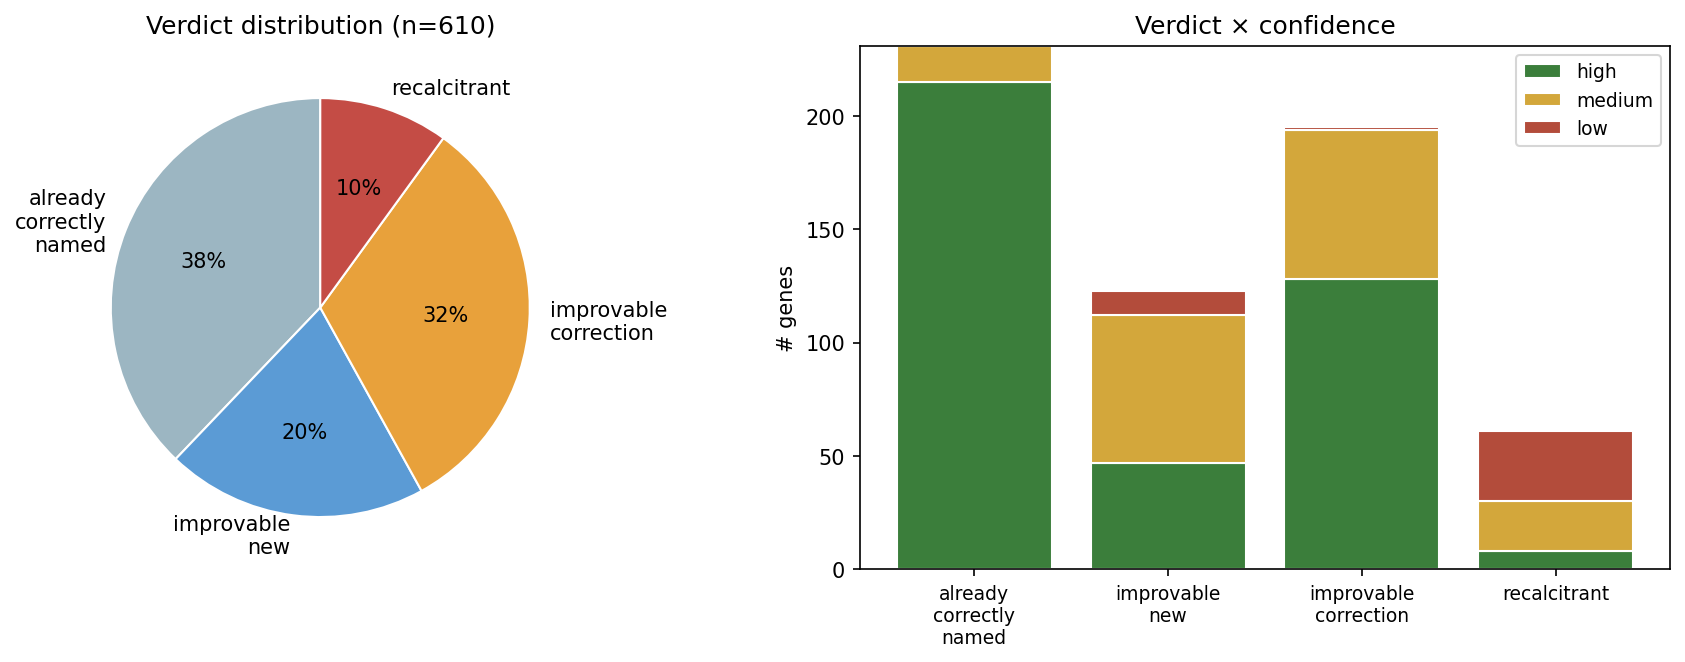

In [7]:
Image(FIGS / "fig01_verdict_distribution.png")

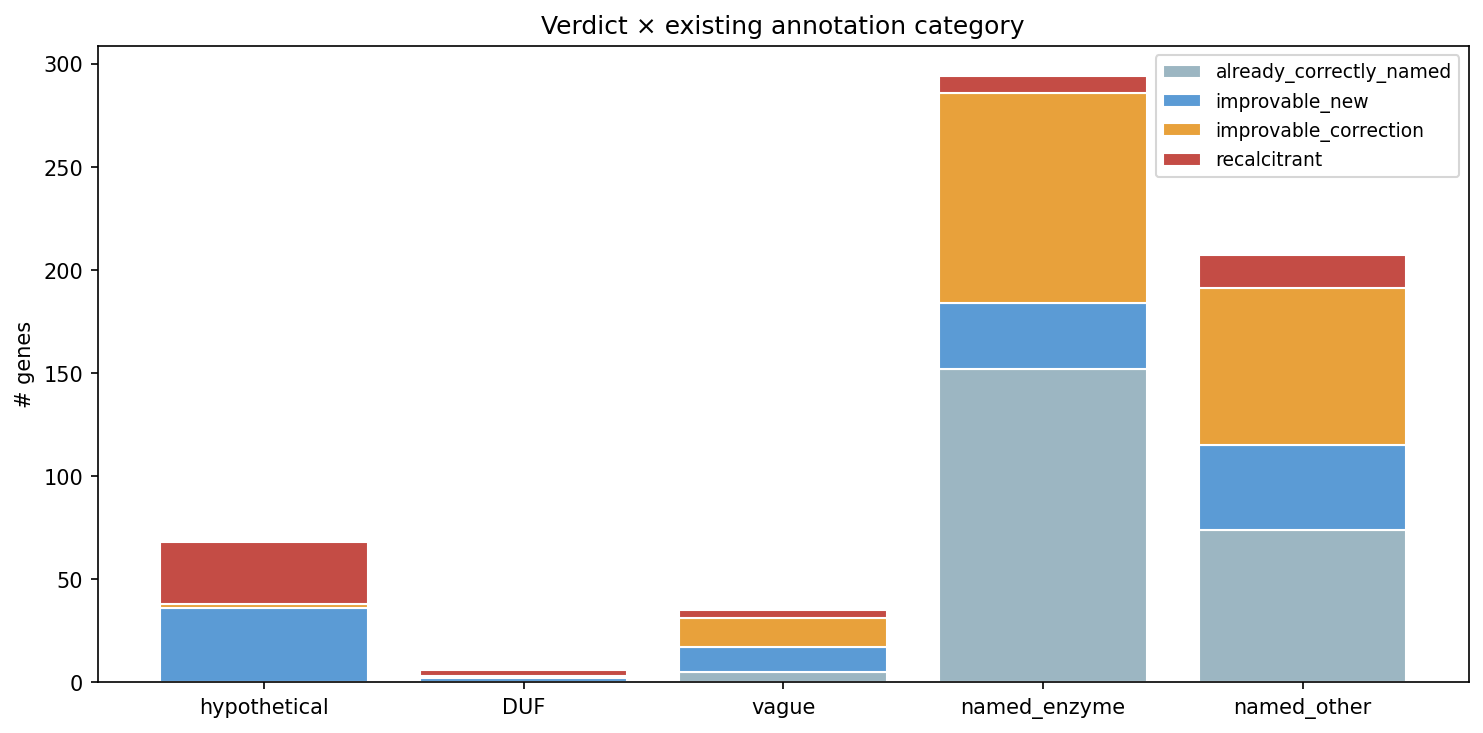

In [8]:
Image(FIGS / "fig02_verdict_by_category.png")

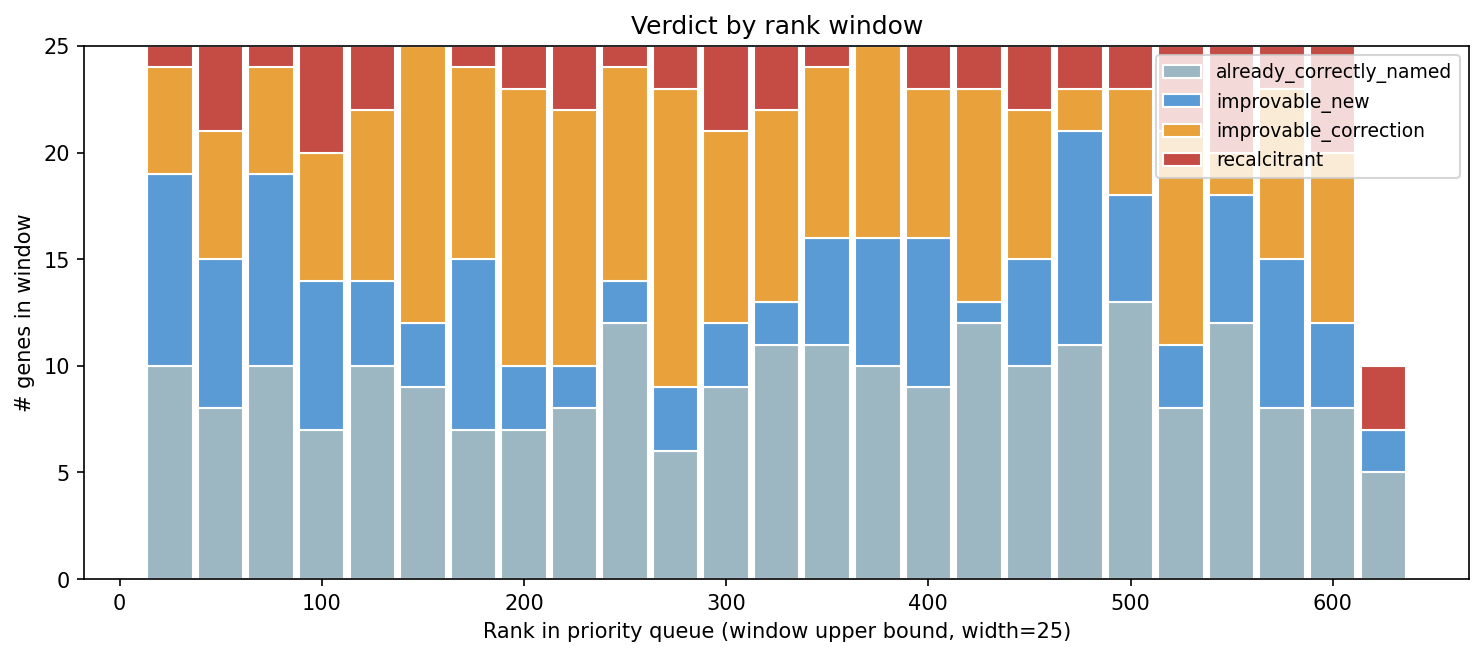

In [9]:
Image(FIGS / "fig03_verdict_by_rank.png")

## Top cross-gene cluster discoveries

PMIDs cited by ≥3 genes — single papers that resolved entire functional
clusters. Full details in [data/cross_gene_clusters.md](../data/cross_gene_clusters.md).

In [10]:
pmids = pd.read_csv(DATA / "cited_pmids.tsv", sep="\t")
clusters = pmids[pmids["n_genes_citing"] >= 3].sort_values("n_genes_citing", ascending=False)
print(f"PMIDs cited by ≥3 genes: {len(clusters)}")
clusters.head(15)

PMIDs cited by ≥3 genes: 24


,pmid,n_genes_citing,verdicts,example_genes
0,24795702,10,"already_correctly_named,improvable_correction,...",Miya::8501457; Miya::8501460; Miya::8501462; M...
1,32934357,9,"already_correctly_named,improvable_correction,...",Miya::8501457; Miya::8501460; Miya::8501462; M...
2,34215744,6,"improvable_correction,improvable_new",PV4::5211094; PV4::5211110; PV4::5211096; PV4:...
3,38771038,6,"improvable_correction,improvable_new,recalcitrant",MR1::202074; MR1::202097; MR1::202069; Miya::8...
4,17114261,5,"already_correctly_named,improvable_correction",WCS417::GFF1390; pseudo6_N2E2::Pf6N2E2_2770; p...
5,37065130,5,"already_correctly_named,improvable_correction,...",DvH::209483; DvH::209482; Miya::8501545; DvH::...
6,18194565,5,improvable_correction,pseudo5_N2C3_1::AO356_21100; pseudo5_N2C3_1::A...
9,21478341,4,"already_correctly_named,improvable_correction",pseudo1_N1B4::Pf1N1B4_2419; WCS417::GFF5140; p...
10,18156257,4,"already_correctly_named,improvable_correction",WCS417::GFF5140; pseudo13_GW456_L13::PfGW456L1...
8,38832093,4,"already_correctly_named,improvable_correction",pseudo6_N2E2::Pf6N2E2_824; pseudo6_N2E2::Pf6N2...


## Sample of high-confidence improvable_correction (existing name was wrong)

In [11]:
corr = df[(df["verdict"] == "improvable_correction") & (df["confidence"] == "high")].copy()
corr_sample = corr.sort_values("rank").head(10)
corr_sample[["rank", "orgId", "locusId", "gene_desc", "proposed_annotation"]]

,rank,orgId,locusId,gene_desc,proposed_annotation
0,6,PV4,5210365,type IV pilus assembly PilZ (RefSeq),MotL-like c-di-GMP-binding PilZ-domain flagell...
5,11,Miya,8501459,multi-sensor signal transduction histidine kin...,Nitrate-sensitivity histidine kinase of the Nt...
8,14,DvH,408291,"sensory box histidine kinase, authentic point ...",Nitrate-sensitivity sensor histidine kinase of...
12,18,Miya,8501458,response regulator receiver protein (RefSeq),NtrX-like sigma54-dependent response regulator...
25,31,Koxy,BWI76_RS08815,cyclic pyranopterin phosphate synthase,Molybdenum cofactor biosynthesis protein MoaA ...
28,34,Cup4G11,RR42_RS10910,aminodeoxychorismate lyase,Endolytic peptidoglycan lytic transglycosylase...
30,36,WCS417,GFF4430,chemotaxis protein CheY,Two-component response regulator GltR-2; activ...
42,48,DvH,206198,molybdenum-pterin binding domain protein/site-...,Molybdate/tungstate-responsive transcriptional...
60,66,pseudo5_N2C3_1,AO356_10715,4-aminobutyrate aminotransferase,5-aminovalerate aminotransferase DavT
65,71,Cup4G11,RR42_RS19475,general secretion pathway protein,type II secretion system protein GspC


## Sample of recalcitrant genes — strong evidence but no proposable annotation

In [12]:
rec = df[df["verdict"] == "recalcitrant"].copy()
rec_sample = rec.sort_values("rank").head(10)
rec_sample[["rank", "orgId", "locusId", "gene_desc", "rationale"]]

,rank,orgId,locusId,gene_desc,rationale
17,23,Kang,B158DRAFT_0100,Na+/proline symporter,Existing annotation 'Na+/proline symporter' is...
20,26,WCS417,GFF1349,methyltransferase,Current 'methyltransferase' (EC 2.1.1.-) is co...
21,27,Marino,GFF3111,TPR repeat containing protein,Specific sensitivity to ionic liquids (1-ethyl...
26,32,Koxy,BWI76_RS06755,sigma factor YlaC,Existing 'sigma factor YlaC' is wrong: SwissPr...
37,43,PV4,5208422,TPR repeat-containing protein (RefSeq),Despite a very strong specific choline-chlorid...
52,58,DvH,208253,hypothetical protein (TIGR),"Despite a strong, very specific phenotype on f..."
73,79,psRCH2,GFF3330,TIGR00645 family protein,TIGR00645 / Pfam UPF0114 family — a deeply con...
74,80,Pedo557,CA265_RS19795,TonB-dependent receptor,Pfam OMP_b-brl_3 (TonB-dependent receptor oute...
75,81,DvH,209483,hypothetical protein (TIGR),Existing annotation is 'hypothetical protein' ...
83,89,Caulo,CCNA_00224,TonB-dependent receptor protein,"Strong, specific phenotype on vancomycin (fit=..."
